# QSVM Rauschrobustheit: Idealer Simulator vs. Noise Models

**Modell:** Quantum Kernel SVM  
**Datensatz:** Iris (3 Klassen, 2 Features) + Breast Cancer (2 Klassen, 2 Features)  
**Backends:** AerSimulator (ideal), AerSimulator + IBM Noise Model (ibm_kingston), Synthetisches Noise Model  
**Referenz:** `01_iris_simulator.ipynb`, `05_breast_cancer_simulator.ipynb`

Untersucht die Robustheit des QSVM gegenüber Quantenrauschen durch systematischen
Vergleich verschiedener Fehlermodelle und einen Fehlerraten-Sweep.


## 0. Imports & Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_ibm_runtime import QiskitRuntimeService

print("Imports OK")
from utils import load_ibm_token


Imports OK


## 1. Datenvorbereitung - identische Pipeline wie 01_iris_simulator

In [2]:
iris = load_iris()
X = iris.data[:, [0, 2]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (105, 2)  |  Test: (45, 2)


## 2. Hilfsfunktionen

In [3]:
def make_noisy_backend(error_1q, error_2q):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(error_1q, 1), ['h', 'x', 'u1', 'u2', 'u3', 'sx', 'rz'])
    nm.add_all_qubit_quantum_error(depolarizing_error(error_2q, 2), ['cx', 'cz'])
    backend = AerSimulator(noise_model=nm)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    sampler = SamplerV2.from_backend(backend)
    return sampler, pm, backend

def make_kernel(sampler, pm=None):
    """Erstellt FidelityQuantumKernel mit zz_feature_map, reps=2."""
    fm = zz_feature_map(feature_dimension=2, reps=2)
    if pm is not None:
        fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)
    else:
        fidelity = ComputeUncompute(sampler=sampler)
    return FidelityQuantumKernel(feature_map=fm, fidelity=fidelity)

def run_qsvm(kernel, X_train, y_train, X_test, y_test):
    svc = SVC(kernel=kernel.evaluate)
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    return svc, y_pred, acc, f1

print("Hilfsfunktionen OK")

Hilfsfunktionen OK


## 3. IBM Noise Model laden (ibm_kingston)

In [4]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token = load_ibm_token()
)
hw_backend = service.backend("ibm_kingston")
noise_model_hw = NoiseModel.from_backend(hw_backend)
noisy_backend_hw = AerSimulator(noise_model=noise_model_hw)
pm_hw = generate_preset_pass_manager(optimization_level=1, backend=noisy_backend_hw)
sampler_hw = SamplerV2.from_backend(noisy_backend_hw)

print(f"Noise Model geladen von: {hw_backend.name}")
print(f"Basis-Gates: {noise_model_hw.basis_gates}")

qiskit_runtime_service._discover_account:WARNING:2026-05-24 13:43:54,467: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-24 13:43:58,018: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-24 13:43:58,021: Using instance: open-instance, plan: open


Noise Model geladen von: ibm_kingston
Basis-Gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']


## 4. QSVM: Ideal vs. IBM Noise vs. Synthetisch

In [5]:
# --- Ideal (StatevectorSampler) ---
sampler_ideal = StatevectorSampler()
kernel_ideal = make_kernel(sampler_ideal)
svc_ideal, y_pred_ideal, acc_ideal, f1_ideal = run_qsvm(
    kernel_ideal, X_train_sc, y_train, X_test_sc, y_test
)
print(f"Ideal        — Accuracy: {acc_ideal:.4f}  F1: {f1_ideal:.4f}")

Ideal        — Accuracy: 0.6222  F1: 0.6160


In [6]:
# --- IBM Noise Model ---
kernel_hw = make_kernel(sampler_hw, pm_hw)
svc_hw, y_pred_hw, acc_hw, f1_hw = run_qsvm(
    kernel_hw, X_train_sc, y_train, X_test_sc, y_test
)
print(f"IBM Noise    — Accuracy: {acc_hw:.4f}  F1: {f1_hw:.4f}")

IBM Noise    — Accuracy: 0.6667  F1: 0.6627


In [7]:
# --- Synthetisches Noise Model (1Q: 0.1%, 2Q: 1%) ---
sampler_syn, pm_syn, _ = make_noisy_backend(0.001, 0.01)
kernel_syn = make_kernel(sampler_syn, pm_syn)
svc_syn, y_pred_syn, acc_syn, f1_syn = run_qsvm(
    kernel_syn, X_train_sc, y_train, X_test_sc, y_test
)
print(f"Synthetisch  — Accuracy: {acc_syn:.4f}  F1: {f1_syn:.4f}")

Synthetisch  — Accuracy: 0.6667  F1: 0.6594


## 5. Kernel-Matrix-Visualisierung

Zeigt direkt wie Rauschen die Ähnlichkeitsstruktur der Kernel-Matrix verzerrt.

Berechne Kernel-Matrizen (dauert einen Moment)...
Ideal fertig.
IBM Noise fertig.
Synthetisch fertig.


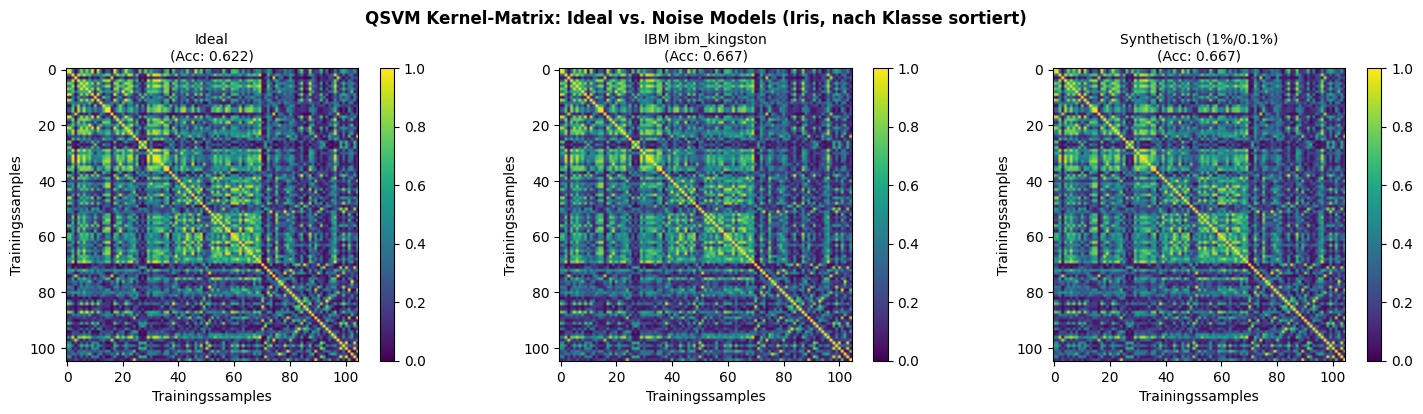

Gespeichert: qsvm_kernel_matrix_noise.png


In [8]:
# Kernel-Matrizen berechnen (nur Trainingsset, sortiert nach Klasse)
sort_idx = np.argsort(y_train)
X_sorted = X_train_sc[sort_idx]

print("Berechne Kernel-Matrizen (dauert einen Moment)...")
K_ideal = kernel_ideal.evaluate(X_sorted)
print("Ideal fertig.")
K_hw    = kernel_hw.evaluate(X_sorted)
print("IBM Noise fertig.")
K_syn   = kernel_syn.evaluate(X_sorted)
print("Synthetisch fertig.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('QSVM Kernel-Matrix: Ideal vs. Noise Models (Iris, nach Klasse sortiert)',
             fontsize=12, fontweight='bold')

titles = [f'Ideal\n(Acc: {acc_ideal:.3f})',
          f'IBM ibm_kingston\n(Acc: {acc_hw:.3f})',
          f'Synthetisch (1%/0.1%)\n(Acc: {acc_syn:.3f})']
matrices = [K_ideal, K_hw, K_syn]

for ax, K, title in zip(axes, matrices, titles):
    im = ax.imshow(K, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Trainingssamples'); ax.set_ylabel('Trainingssamples')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('Ergebnisse/qsvm_kernel_matrix_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: qsvm_kernel_matrix_noise.png")

## 6. Fehlerraten-Sweep - Ab wann bricht QSVM ein?

Identische Fehlerraten wie 07_vqc_konvergenz_analyse (VQC) für direkten Vergleich:  
2Q-Fehlerraten: 0.1%, 0.3%, 0.5%, 1%, 2%, 5%  
1Q-Fehlerrate jeweils 10x kleiner.

In [9]:
ERROR_RATES_2Q = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]

sweep_results = []

for err_2q in ERROR_RATES_2Q:
    err_1q = err_2q / 10
    print(f"2Q-Fehlerrate: {err_2q*100:.1f}%  |  1Q: {err_1q*100:.2f}% ...", end=' ', flush=True)

    sampler_s, pm_s, _ = make_noisy_backend(err_1q, err_2q)
    kernel_s = make_kernel(sampler_s, pm_s)
    _, _, acc_s, f1_s = run_qsvm(kernel_s, X_train_sc, y_train, X_test_sc, y_test)

    print(f"Accuracy: {acc_s:.4f}  F1: {f1_s:.4f}")
    sweep_results.append({'err_2q': err_2q, 'err_1q': err_1q, 'accuracy': acc_s, 'f1': f1_s})

print("\nSweep abgeschlossen.")

2Q-Fehlerrate: 0.1%  |  1Q: 0.01% ... Accuracy: 0.6667  F1: 0.6628
2Q-Fehlerrate: 0.3%  |  1Q: 0.03% ... Accuracy: 0.6667  F1: 0.6638
2Q-Fehlerrate: 0.5%  |  1Q: 0.05% ... Accuracy: 0.6444  F1: 0.6375
2Q-Fehlerrate: 1.0%  |  1Q: 0.10% ... Accuracy: 0.6444  F1: 0.6389
2Q-Fehlerrate: 2.0%  |  1Q: 0.20% ... Accuracy: 0.6667  F1: 0.6628
2Q-Fehlerrate: 5.0%  |  1Q: 0.50% ... Accuracy: 0.6667  F1: 0.6628

Sweep abgeschlossen.


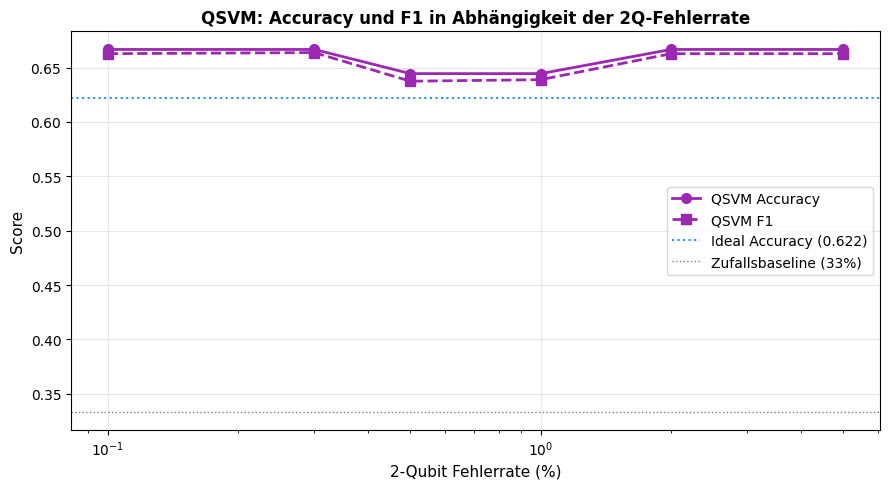

Gespeichert: qsvm_fehlerrate_sweep.png

 err_2q_pct  accuracy       f1
        0.1  0.666667 0.662785
        0.3  0.666667 0.663793
        0.5  0.644444 0.637486
        1.0  0.644444 0.638889
        2.0  0.666667 0.662785
        5.0  0.666667 0.662785


In [10]:
df_sweep = pd.DataFrame(sweep_results)
df_sweep['err_2q_pct'] = df_sweep['err_2q'] * 100

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_sweep['err_2q_pct'], df_sweep['accuracy'],
        marker='o', color='#9C27B0', linewidth=2, markersize=7, label='QSVM Accuracy')
ax.plot(df_sweep['err_2q_pct'], df_sweep['f1'],
        marker='s', color='#9C27B0', linewidth=2, markersize=7, linestyle='--', label='QSVM F1')
ax.axhline(acc_ideal, color='#2196F3', linestyle=':', linewidth=1.5, label=f'Ideal Accuracy ({acc_ideal:.3f})')
ax.axhline(1/3, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline (33%)')

ax.set_xscale('log')
ax.set_xlabel('2-Qubit Fehlerrate (%)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('QSVM: Accuracy und F1 in Abhängigkeit der 2Q-Fehlerrate', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Ergebnisse/qsvm_fehlerrate_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: qsvm_fehlerrate_sweep.png")

print()
print(df_sweep[['err_2q_pct', 'accuracy', 'f1']].to_string(index=False))

## 7. Vergleich VQC vs. QSVM (Sweep-Ergebnisse zusammenführen)

Nutzt die VQC-Sweep-Ergebnisse aus NB07 und stellt beide nebeneinander.  
! Erst ausführen nachdem NB07 komplett durchgelaufen ist. !

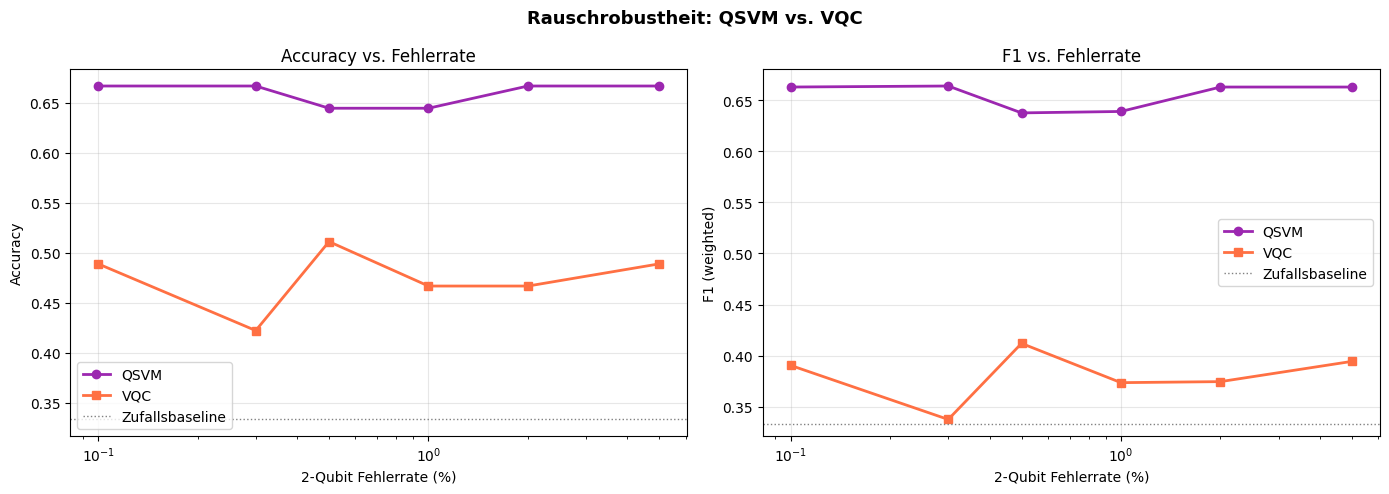

Gespeichert: qsvm_vs_vqc_rauschrobustheit.png


In [24]:
# QSVM vs. VQC Vergleich — Iris
vqc_acc_sweep = [0.4889, 0.4222, 0.5111, 0.4667, 0.4667, 0.4889]
vqc_f1_sweep  = [0.3905, 0.3376, 0.4120, 0.3736, 0.3746, 0.3944]

if len(vqc_acc_sweep) == len(ERROR_RATES_2Q):
    err_pct = [e * 100 for e in ERROR_RATES_2Q]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Rauschrobustheit: QSVM vs. VQC', fontsize=13, fontweight='bold')

    for ax, metric, qsvm_vals, vqc_vals, ylabel in zip(
        axes,
        ['Accuracy', 'F1'],
        [df_sweep['accuracy'].tolist(), df_sweep['f1'].tolist()],
        [vqc_acc_sweep, vqc_f1_sweep],
        ['Accuracy', 'F1 (weighted)']
    ):
        ax.plot(err_pct, qsvm_vals, marker='o', color='#9C27B0', linewidth=2, label='QSVM')
        ax.plot(err_pct, vqc_vals,  marker='s', color='#FF7043', linewidth=2, label='VQC')
        ax.axhline(1/3, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline')
        ax.set_xscale('log')
        ax.set_xlabel('2-Qubit Fehlerrate (%)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{metric} vs. Fehlerrate')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('Ergebnisse/qsvm_vs_vqc_rauschrobustheit.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Gespeichert: qsvm_vs_vqc_rauschrobustheit.png")
else:
    print("VQC-Sweep-Werte noch nicht eingetragen — erst 07_vqc_konvergenz_analyse ausführen.")

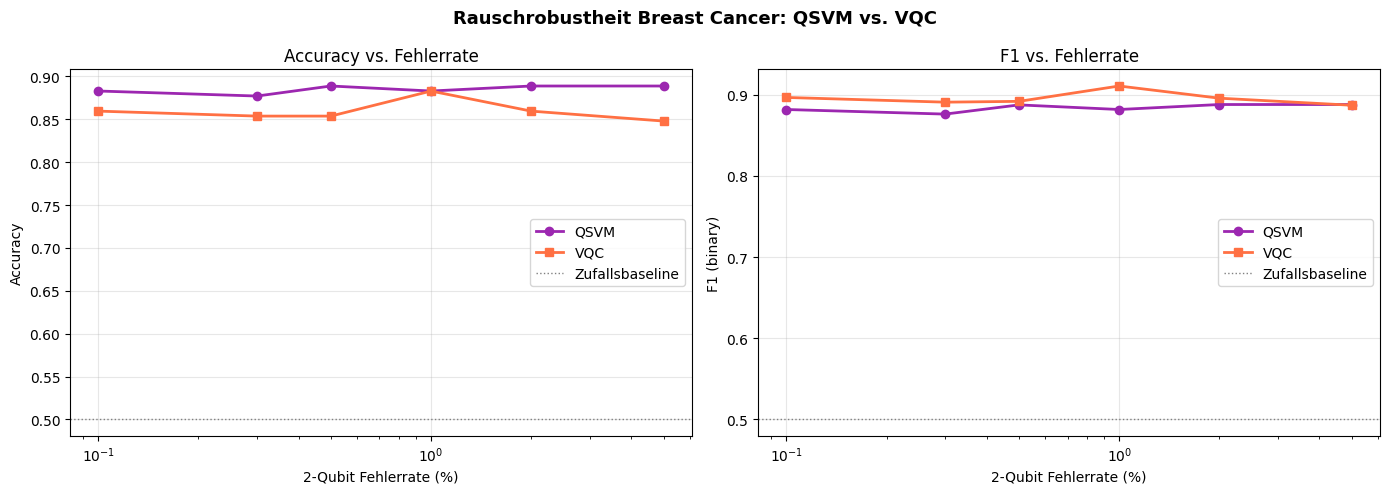

Gespeichert: qsvm_vs_vqc_rauschrobustheit_bc.png


In [23]:
# QSVM vs. VQC Vergleich — Breast Cancer
vqc_acc_sweep_bc = [0.8596, 0.8538, 0.8538, 0.8830, 0.8596, 0.8480]
vqc_f1_sweep_bc  = [0.8966, 0.8908, 0.8918, 0.9107, 0.8957, 0.8870]

err_pct = [e * 100 for e in ERROR_RATES_2Q]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rauschrobustheit Breast Cancer: QSVM vs. VQC', fontsize=13, fontweight='bold')

for ax, metric, qsvm_vals, vqc_vals, ylabel in zip(
    axes,
    ['Accuracy', 'F1'],
    [df_sweep_bc['accuracy'].tolist(), df_sweep_bc['f1'].tolist()],
    [vqc_acc_sweep_bc, vqc_f1_sweep_bc],
    ['Accuracy', 'F1 (binary)']
):
    ax.plot(err_pct, qsvm_vals, marker='o', color='#9C27B0', linewidth=2, label='QSVM')
    ax.plot(err_pct, vqc_vals,  marker='s', color='#FF7043', linewidth=2, label='VQC')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline')
    ax.set_xscale('log')
    ax.set_xlabel('2-Qubit Fehlerrate (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} vs. Fehlerrate')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Ergebnisse/qsvm_vs_vqc_rauschrobustheit_bc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: qsvm_vs_vqc_rauschrobustheit_bc.png")

## 8. Zusammenfassung

In [12]:
print("=" * 60)
print(f"{'Bedingung':<35} {'Accuracy':>10} {'F1':>8}")
print("-" * 60)
print(f"{'Idealer Simulator':<35} {acc_ideal:>10.4f} {f1_ideal:>8.4f}")
print(f"{'Noise Model (ibm_kingston)':<35} {acc_hw:>10.4f} {f1_hw:>8.4f}")
print(f"{'Noise synthetisch (1%/0.1%)':<35} {acc_syn:>10.4f} {f1_syn:>8.4f}")
print("=" * 60)
print()
print("Fehlerraten-Sweep (2Q-Fehlerrate → Accuracy):")
for r in sweep_results:
    print(f"  {r['err_2q']*100:.1f}%  →  {r['accuracy']:.4f}")

Bedingung                             Accuracy       F1
------------------------------------------------------------
Idealer Simulator                       0.6222   0.6160
Noise Model (ibm_kingston)              0.6667   0.6627
Noise synthetisch (1%/0.1%)             0.6667   0.6594

Fehlerraten-Sweep (2Q-Fehlerrate → Accuracy):
  0.1%  →  0.6667
  0.3%  →  0.6667
  0.5%  →  0.6444
  1.0%  →  0.6444
  2.0%  →  0.6667
  5.0%  →  0.6667


## 9. Breast Cancer - Datenvorbereitung

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc
)

pca = PCA(n_components=2, random_state=42)
X_train_bc_pca = pca.fit_transform(X_train_bc)
X_test_bc_pca  = pca.transform(X_test_bc)

scaler_bc = MinMaxScaler(feature_range=(0, 2 * np.pi))
X_train_bc_sc = scaler_bc.fit_transform(X_train_bc_pca)
X_test_bc_sc  = scaler_bc.transform(X_test_bc_pca)

print(f"Erklärte Varianz: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Train: {X_train_bc_sc.shape}  |  Test: {X_test_bc_sc.shape}")

Erklärte Varianz: 99.93%
Train: (398, 2)  |  Test: (171, 2)


## 10. QSVM Breast Cancer - Ideal vs. IBM Noise vs. Synthetisch

! Laufzeit: QSVM auf BC ist O(n²) - Training + Inferenz kann mehrere Stunden dauern. Über Nacht laufen lassen. !

In [14]:
# --- Ideal ---
kernel_bc_ideal = make_kernel(StatevectorSampler())
svc_bc_ideal, y_pred_bc_ideal, acc_bc_ideal, f1_bc_ideal = run_qsvm(
    kernel_bc_ideal, X_train_bc_sc, y_train_bc, X_test_bc_sc, y_test_bc
)
print(f"Ideal        - Accuracy: {acc_bc_ideal:.4f}  F1: {f1_bc_ideal:.4f}")

Ideal        — Accuracy: 0.8830  F1: 0.8822


In [15]:
# --- IBM Noise Model ---
kernel_bc_hw = make_kernel(sampler_hw, pm_hw)
svc_bc_hw, y_pred_bc_hw, acc_bc_hw, f1_bc_hw = run_qsvm(
    kernel_bc_hw, X_train_bc_sc, y_train_bc, X_test_bc_sc, y_test_bc
)
print(f"IBM Noise    - Accuracy: {acc_bc_hw:.4f}  F1: {f1_bc_hw:.4f}")

IBM Noise    — Accuracy: 0.8713  F1: 0.8705


In [16]:
# --- Synthetisches Noise Model ---
sampler_bc_syn, pm_bc_syn, _ = make_noisy_backend(0.001, 0.01)
kernel_bc_syn = make_kernel(sampler_bc_syn, pm_bc_syn)
svc_bc_syn, y_pred_bc_syn, acc_bc_syn, f1_bc_syn = run_qsvm(
    kernel_bc_syn, X_train_bc_sc, y_train_bc, X_test_bc_sc, y_test_bc
)
print(f"Synthetisch  - Accuracy: {acc_bc_syn:.4f}  F1: {f1_bc_syn:.4f}")

Synthetisch  — Accuracy: 0.8889  F1: 0.8879


## 11. Kernel-Matrix-Visualisierung Breast Cancer

Berechne Kernel-Matrizen BC (dauert einen Moment)...
Ideal fertig.
IBM Noise fertig.
Synthetisch fertig.


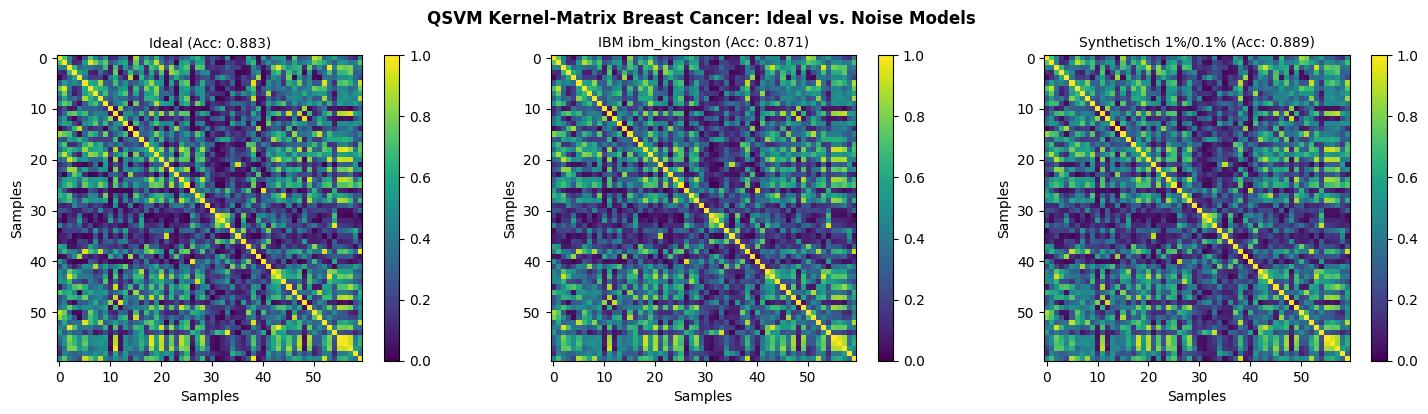

Gespeichert: qsvm_kernel_matrix_bc_noise.png


In [18]:
# Sortiert nach Klasse, nur erste 60 Samples für Übersichtlichkeit
sort_idx_bc = np.argsort(y_train_bc)[:60]
X_bc_sorted = X_train_bc_sc[sort_idx_bc]

print("Berechne Kernel-Matrizen BC (dauert einen Moment)...")
K_bc_ideal = kernel_bc_ideal.evaluate(X_bc_sorted); print("Ideal fertig.")
K_bc_hw    = kernel_bc_hw.evaluate(X_bc_sorted);    print("IBM Noise fertig.")
K_bc_syn   = kernel_bc_syn.evaluate(X_bc_sorted);   print("Synthetisch fertig.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('QSVM Kernel-Matrix Breast Cancer: Ideal vs. Noise Models', fontsize=12, fontweight='bold')

titles = [
    f'Ideal (Acc: {acc_bc_ideal:.3f})',
    f'IBM ibm_kingston (Acc: {acc_bc_hw:.3f})',
    f'Synthetisch 1%/0.1% (Acc: {acc_bc_syn:.3f})'
]
matrices = [K_bc_ideal, K_bc_hw, K_bc_syn]

for ax, K, title in zip(axes, matrices, titles):
    im = ax.imshow(K, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Samples'); ax.set_ylabel('Samples')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('Ergebnisse/qsvm_kernel_matrix_bc_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: qsvm_kernel_matrix_bc_noise.png")

## 12. Fehlerraten-Sweep Breast Cancer

! Laufzeit: 6 Stufen × O(n²) Kernel ! 

In [20]:
sweep_results_bc = []

for err_2q in ERROR_RATES_2Q:
    err_1q = err_2q / 10
    print(f"2Q-Fehlerrate: {err_2q*100:.1f}%  |  1Q: {err_1q*100:.2f}% ...", end=' ', flush=True)

    sampler_s, pm_s, _ = make_noisy_backend(err_1q, err_2q)
    kernel_s = make_kernel(sampler_s, pm_s)
    _, _, acc_s, f1_s = run_qsvm(kernel_s, X_train_bc_sc, y_train_bc, X_test_bc_sc, y_test_bc)

    print(f"Accuracy: {acc_s:.4f}  F1: {f1_s:.4f}")
    sweep_results_bc.append({'err_2q': err_2q, 'err_1q': err_1q, 'accuracy': acc_s, 'f1': f1_s})

print("Sweep BC abgeschlossen.")

2Q-Fehlerrate: 0.1%  |  1Q: 0.01% ... Accuracy: 0.8830  F1: 0.8818
2Q-Fehlerrate: 0.3%  |  1Q: 0.03% ... Accuracy: 0.8772  F1: 0.8761
2Q-Fehlerrate: 0.5%  |  1Q: 0.05% ... Accuracy: 0.8889  F1: 0.8874
2Q-Fehlerrate: 1.0%  |  1Q: 0.10% ... Accuracy: 0.8830  F1: 0.8818
2Q-Fehlerrate: 2.0%  |  1Q: 0.20% ... Accuracy: 0.8889  F1: 0.8879
2Q-Fehlerrate: 5.0%  |  1Q: 0.50% ... Accuracy: 0.8889  F1: 0.8879
Sweep BC abgeschlossen.


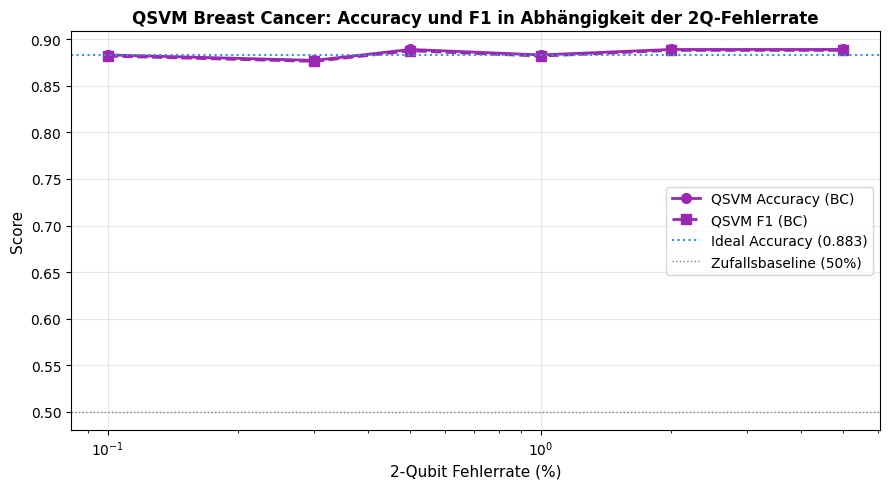

Gespeichert: qsvm_fehlerrate_sweep_bc.png

 err_2q_pct  accuracy       f1
        0.1  0.883041 0.881760
        0.3  0.877193 0.876099
        0.5  0.888889 0.887435
        1.0  0.883041 0.881760
        2.0  0.888889 0.887899
        5.0  0.888889 0.887899


In [21]:
import pandas as pd

df_sweep_bc = pd.DataFrame(sweep_results_bc)
df_sweep_bc['err_2q_pct'] = df_sweep_bc['err_2q'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sweep_bc['err_2q_pct'], df_sweep_bc['accuracy'],
        marker='o', color='#9C27B0', linewidth=2, markersize=7, label='QSVM Accuracy (BC)')
ax.plot(df_sweep_bc['err_2q_pct'], df_sweep_bc['f1'],
        marker='s', color='#9C27B0', linewidth=2, markersize=7, linestyle='--', label='QSVM F1 (BC)')
ax.axhline(acc_bc_ideal, color='#2196F3', linestyle=':', linewidth=1.5, label=f'Ideal Accuracy ({acc_bc_ideal:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline (50%)')
ax.set_xscale('log')
ax.set_xlabel('2-Qubit Fehlerrate (%)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('QSVM Breast Cancer: Accuracy und F1 in Abhängigkeit der 2Q-Fehlerrate', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Ergebnisse/qsvm_fehlerrate_sweep_bc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: qsvm_fehlerrate_sweep_bc.png")
print()
print(df_sweep_bc[['err_2q_pct', 'accuracy', 'f1']].to_string(index=False))